# Neuronales Netz: einfacher Modellvergleich

**Leitfrage:** Verbessert ein kleines neuronales Netz die logistische Regression, und
veraendert sich das Ergebnis, wenn die `calc`-Merkmale weggelassen werden?

Die logistische Regression dient als Baseline. Mein eigener Beitrag ist das MLP und der
Vergleich mit und ohne `calc`.

In [1]:
import json, os, time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn

from sklearn.compose import ColumnTransformer
from sklearn.datasets import fetch_openml
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils.class_weight import compute_sample_weight

RANDOM_STATE, TEST_SIZE = 42, 0.20
BATCH_SIZE, MAX_ITER = 1024, 100
ABB_DIR = os.path.join("ergebnisse", "abbildungen")
ERG_JSON = os.path.join("ergebnisse", "ergebnisse_neural_network.json")
os.makedirs(ABB_DIR, exist_ok=True)

VERSIONEN = {"python": __import__("sys").version.split()[0],
             "scikit-learn": sklearn.__version__, "numpy": np.__version__,
             "pandas": pd.__version__,
             "matplotlib": __import__("matplotlib").__version__}
FARBEN = {"LogReg": "#2a78d6", "MLP": "#eb6834", "MLP ohne calc": "#4a3aa7"}

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight", "font.size": 9,
    "axes.titlesize": 10, "axes.titleweight": "bold", "axes.spines.top": False,
    "axes.spines.right": False, "axes.grid": True, "grid.color": "#e1e0d9"})

def speichern(fig, name):
    fig.savefig(os.path.join(ABB_DIR, name)); plt.show()

def tsd(zahl):
    return f"{zahl:,}".replace(",", " ")

## 1. Daten und Metriken

Der Datensatz wird ueber OpenML geladen. Normalized Gini ist die Hauptmetrik; ROC-AUC und
PR-AUC werden ergaenzend berichtet. Bei stark ungleichen Klassen ist Accuracy allein wenig
aussagekraeftig.

In [2]:
def normalized_gini(y_true, y_score):
    return 2 * roc_auc_score(y_true, y_score) - 1

def kennzahlen(y_true, y_score):
    return {"gini": normalized_gini(y_true, y_score),
            "roc_auc": roc_auc_score(y_true, y_score),
            "pr_auc": average_precision_score(y_true, y_score)}

def trainiere(pipeline, **fit_parameter):
    start = time.perf_counter()
    pipeline.fit(X_train, y_train, **fit_parameter)
    return time.perf_counter() - start

daten = fetch_openml(data_id=42742, as_frame=True)
X, y = daten.data.copy(), daten.target.astype(int).to_numpy()
kategorie_spalten = [c for c in X.columns if str(X[c].dtype) == "category"]
X[kategorie_spalten] = X[kategorie_spalten].apply(
    lambda spalte: pd.to_numeric(spalte.astype("object")))
print(f"{tsd(X.shape[0])} Zeilen x {X.shape[1]} Features | "
      f"Zielklassen {sorted(np.unique(y).tolist())}")

595 212 Zeilen x 57 Features | Zielklassen [0, 1]


## 2. Modellbezogene EDA

Die eigene EDA betrachtet die Punkte, aus denen direkte Modellentscheidungen folgen:
Klassenverteilung, fehlende Werte und kategoriale Merkmale. Die breitere Gruppen-EDA mit
Korrelationen und Zielbeziehungen steht in
[`ADA_Analyse_Amine.ipynb`](../notebook_amine/ADA_Analyse_Amine.ipynb).

### 2.1 Klassenverteilung

Klasse 0: 573 518 (96.3552 %) | Klasse 1: 21 694 (3.6448 %) | Verhaeltnis 26.4 : 1


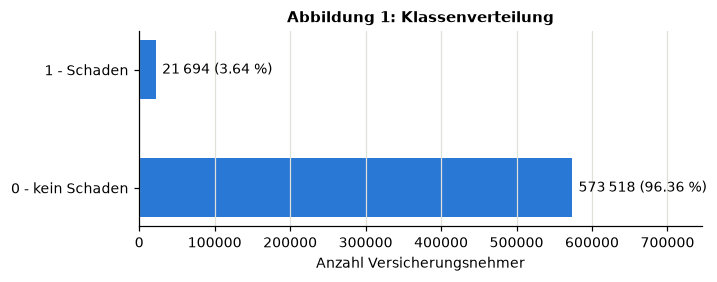

In [3]:
anzahl = pd.Series(y).value_counts().sort_index()
anteil = anzahl / anzahl.sum()
print(f"Klasse 0: {tsd(int(anzahl.iloc[0]))} ({anteil.iloc[0] * 100:.4f} %) | "
      f"Klasse 1: {tsd(int(anzahl.iloc[1]))} ({anteil.iloc[1] * 100:.4f} %) | "
      f"Verhaeltnis {anzahl.iloc[0] / anzahl.iloc[1]:.1f} : 1")

fig, ax = plt.subplots(figsize=(6.6, 2.3)); ax.grid(axis="y", visible=False)
ax.barh([0, 1], anzahl.values, height=0.5, color="#2a78d6")
for position, wert, quote in zip([0, 1], anzahl.values, anteil.values):
    ax.text(wert + anzahl.max() * 0.015, position,
            f"{tsd(int(wert))} ({quote * 100:.2f} %)", va="center")
ax.set_yticks([0, 1]); ax.set_yticklabels(["0 - kein Schaden", "1 - Schaden"])
ax.set_xlim(0, anzahl.max() * 1.30); ax.set_xlabel("Anzahl Versicherungsnehmer")
ax.set_title("Abbildung 1: Klassenverteilung")
speichern(fig, "nn_01_klassenverteilung.png")

**Abbildung 1:** Nur 3,64 Prozent der Beobachtungen gehoeren zur positiven Klasse. Deshalb
werden die Modelle gewichtet und mit Gini, ROC-AUC und PR-AUC bewertet.

### 2.2 Fehlende Werte

13 von 57 Spalten enthalten fehlende Werte.


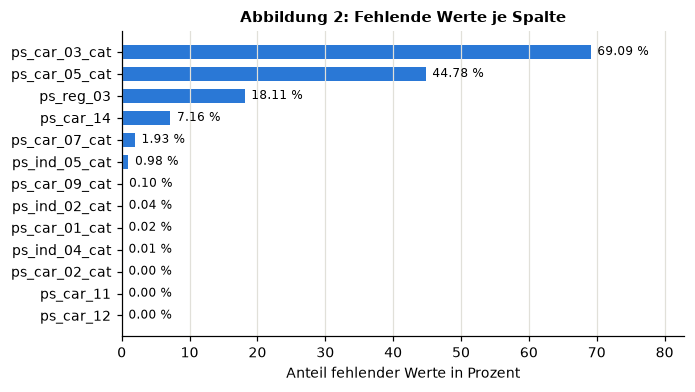

In [4]:
fehlend = X.isna().mean()
fehlend = fehlend[fehlend > 0].sort_values(ascending=False)
print(f"{len(fehlend)} von {X.shape[1]} Spalten enthalten fehlende Werte.")

fig, ax = plt.subplots(figsize=(6.6, 3.6)); ax.grid(axis="y", visible=False)
positionen = np.arange(len(fehlend))[::-1]
ax.barh(positionen, fehlend.values * 100, height=0.62, color="#2a78d6")
for position, wert in zip(positionen, fehlend.values * 100):
    ax.text(wert + 1.0, position, f"{wert:.2f} %", va="center", fontsize=8)
ax.set_yticks(positionen); ax.set_yticklabels(fehlend.index)
ax.set_xlim(0, fehlend.max() * 120); ax.set_xlabel("Anteil fehlender Werte in Prozent")
ax.set_title("Abbildung 2: Fehlende Werte je Spalte")
speichern(fig, "nn_02_fehlende_werte.png")

**Abbildung 2:** Fehlende kategoriale Werte werden mit dem haeufigsten Wert ersetzt,
numerische Werte mit dem Median.

### 2.3 Kategoriale Merkmale

In [5]:
kategorial = [c for c in X.columns if c.endswith("_cat")]
kardinalitaet = X[kategorial].nunique().sort_values(ascending=False)
print(kardinalitaet.to_string())
print()
print(f"{len(kategorial)} kategoriale Merkmale ergeben "
      f"{int(kardinalitaet.sum())} One-Hot-Spalten.")

ps_car_11_cat    104
ps_car_06_cat     18
ps_car_01_cat     12
ps_car_04_cat     10
ps_ind_05_cat      7
ps_car_09_cat      5
ps_ind_02_cat      4
ps_car_10_cat      3
ps_ind_04_cat      2
ps_car_02_cat      2
ps_car_03_cat      2
ps_car_05_cat      2
ps_car_07_cat      2
ps_car_08_cat      2

14 kategoriale Merkmale ergeben 175 One-Hot-Spalten.


Die kategorialen Merkmale werden one-hot-kodiert. Numerische Merkmale werden standardisiert,
weil LogReg und MLP mit vergleichbaren Groessenordnungen besser arbeiten.

## 3. Train-Test-Split

80 Prozent der Daten werden fuer Training und internes Early Stopping genutzt. Die
restlichen 20 Prozent bleiben bis zur abschliessenden Auswertung unberuehrt. Der Split ist
stratifiziert, damit die seltene positive Klasse in beiden Teilen gleich vertreten ist.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)
split_tabelle = pd.DataFrame({
    "Zeilen": [len(y_train), len(y_test)],
    "Positive": [int(y_train.sum()), int(y_test.sum())],
    "Positivrate in %": [100 * y_train.mean(), 100 * y_test.mean()]},
    index=["Training", "Test"])
print(split_tabelle.round(4).to_string())

          Zeilen  Positive  Positivrate in %
Training  476169     17355            3.6447
Test      119043      4339            3.6449


## 4. Vorverarbeitung

Die Vorverarbeitung liegt in einer Pipeline und wird nur auf den Trainingsdaten angepasst.
Damit gelangen keine Informationen aus dem Testset in das Training.

In [7]:
BIN_SPALTEN = [c for c in X.columns if c.endswith("_bin")]
CAT_SPALTEN = [c for c in X.columns if c.endswith("_cat")]
NUM_SPALTEN = [c for c in X.columns
               if not c.endswith("_bin") and not c.endswith("_cat")]
CALC_SPALTEN = [c for c in X.columns if "calc" in c]

def baue_vorverarbeitung(ohne_calc=False):
    def auswahl(spalten):
        return [c for c in spalten if "calc" not in c] if ohne_calc else spalten

    return ColumnTransformer([
        ("bin", "passthrough", auswahl(BIN_SPALTEN)),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("one_hot", OneHotEncoder(handle_unknown="ignore"))]),
         auswahl(CAT_SPALTEN)),
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("skalierung", StandardScaler())]),
         auswahl(NUM_SPALTEN))],
        sparse_threshold=0.3)

print(f"_bin: {len(BIN_SPALTEN)} | _cat: {len(CAT_SPALTEN)} | "
      f"ordinal/stetig: {len(NUM_SPALTEN)} | calc: {len(CALC_SPALTEN)}")

_bin: 17 | _cat: 14 | ordinal/stetig: 26 | calc: 20


## 5. Logistische Regression

Die logistische Regression ist die einfache Baseline. `class_weight="balanced"` gleicht die
ungleichen Klassen im Training aus.

In [8]:
ergebnisse = {}
logreg = Pipeline([
    ("vorverarbeitung", baue_vorverarbeitung()),
    ("modell", LogisticRegression(
        class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE))])

zeit_logreg = trainiere(logreg)
ergebnisse["LogReg"] = {
    "pipeline": logreg, "fit_sekunden": zeit_logreg,
    "epochen_iterationen": int(logreg["modell"].n_iter_[0]),
    "features": int(logreg["modell"].coef_.shape[1])}
print(f"Fitzeit: {zeit_logreg:.1f} s | "
      f"Iterationen: {logreg['modell'].n_iter_[0]} | "
      f"Features: {logreg['modell'].coef_.shape[1]}")

Fitzeit: 12.9 s | Iterationen: 106 | Features: 218


## 6. Kleines neuronales Netz

Das MLP besitzt eine versteckte Schicht mit 64 Neuronen. Early Stopping reserviert intern
10 Prozent der Trainingsdaten und beendet das Training, wenn sich der Validierungswert zehn
Epochen lang nicht verbessert. `max_iter=100` ist nur die Obergrenze.

Der Vorteil ist die einfache, standardisierte Anwendung. Die Grenze ist, dass scikit-learn
dabei Accuracy und nicht Gini ueberwacht.

In [9]:
sample_weights = compute_sample_weight("balanced", y_train)

def baue_mlp(ohne_calc=False):
    return Pipeline([
        ("vorverarbeitung", baue_vorverarbeitung(ohne_calc)),
        ("modell", MLPClassifier(
            hidden_layer_sizes=(64,), activation="relu", solver="adam",
            alpha=1e-4, learning_rate_init=1e-3, batch_size=BATCH_SIZE,
            early_stopping=True, validation_fraction=0.1,
            n_iter_no_change=10, max_iter=MAX_ITER,
            random_state=RANDOM_STATE))])

mlp = baue_mlp()
zeit_mlp = trainiere(mlp, modell__sample_weight=sample_weights)
mlp_modell = mlp["modell"]
ergebnisse["MLP"] = {
    "pipeline": mlp, "fit_sekunden": zeit_mlp,
    "epochen_iterationen": int(mlp_modell.n_iter_),
    "features": int(mlp_modell.coefs_[0].shape[0])}
print(f"Fitzeit: {zeit_mlp:.1f} s | Early Stopping nach "
      f"{mlp_modell.n_iter_} von maximal {MAX_ITER} Epochen | "
      f"Features: {mlp_modell.coefs_[0].shape[0]}")

Fitzeit: 33.1 s | Early Stopping nach 16 von maximal 100 Epochen | Features: 218


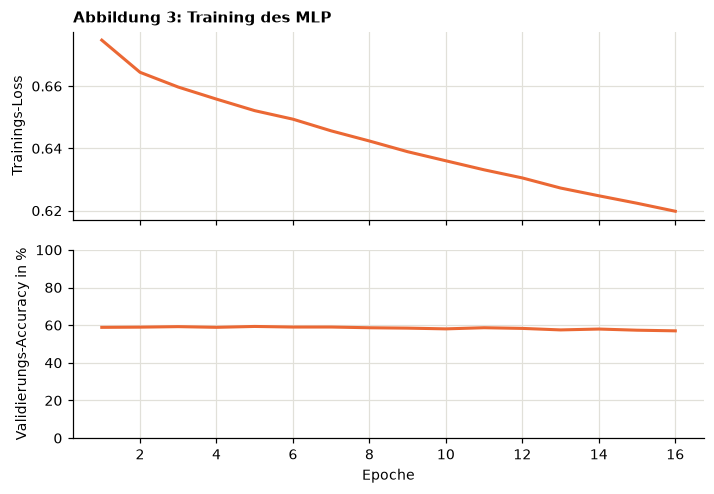

In [10]:
epochen = np.arange(1, mlp_modell.n_iter_ + 1)
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(7.4, 4.8), sharex=True, gridspec_kw={"hspace": 0.16})
ax1.plot(epochen, mlp_modell.loss_curve_, color=FARBEN["MLP"], linewidth=2)
ax1.set_ylabel("Trainings-Loss")
ax1.set_title("Abbildung 3: Training des MLP", loc="left")
ax2.plot(epochen, np.array(mlp_modell.validation_scores_) * 100,
         color=FARBEN["MLP"], linewidth=2)
ax2.set_ylabel("Validierungs-Accuracy in %")
ax2.set_xlabel("Epoche"); ax2.set_ylim(0, 100)
speichern(fig, "nn_03_mlp_training.png")

**Abbildung 3:** Der Trainings-Loss sinkt. Das automatische Early Stopping beendet das
Training, sobald sich die interne Validierungs-Accuracy nicht mehr ausreichend verbessert.

## 7. Vergleich ohne `calc`

Die dokumentierte Gewinnerloesung verzichtete auf die anonymisierten `calc`-Merkmale
(Jahrer 2017). Das bedeutet nicht, dass sie allgemein nutzlos sind. Deshalb wird dasselbe
MLP ein zweites Mal ohne diese 20 Merkmale trainiert.

In [11]:
mlp_ohne_calc = baue_mlp(ohne_calc=True)
zeit_ohne_calc = trainiere(
    mlp_ohne_calc, modell__sample_weight=sample_weights)
modell_ohne_calc = mlp_ohne_calc["modell"]
ergebnisse["MLP ohne calc"] = {
    "pipeline": mlp_ohne_calc, "fit_sekunden": zeit_ohne_calc,
    "epochen_iterationen": int(modell_ohne_calc.n_iter_),
    "features": int(modell_ohne_calc.coefs_[0].shape[0])}
print(f"{len(CALC_SPALTEN)} calc-Merkmale entfernt | "
      f"Features: {mlp_modell.coefs_[0].shape[0]} -> "
      f"{modell_ohne_calc.coefs_[0].shape[0]} | "
      f"Early Stopping nach {modell_ohne_calc.n_iter_} Epochen")

20 calc-Merkmale entfernt | Features: 218 -> 198 | Early Stopping nach 19 Epochen


## 8. Auswertung auf dem Testset

Alle drei Modelle werden jetzt einmal auf demselben Testset ausgewertet.

In [12]:
zeilen = []
for name, eintrag in ergebnisse.items():
    proba = eintrag["pipeline"].predict_proba(X_test)[:, 1]
    eintrag["test"] = kennzahlen(y_test, proba)
    zeilen.append({
        "Modell": name,
        "Gini": round(eintrag["test"]["gini"], 4),
        "Delta zur Baseline": round(
            eintrag["test"]["gini"] - ergebnisse["LogReg"]["test"]["gini"], 4),
        "ROC-AUC": round(eintrag["test"]["roc_auc"], 4),
        "PR-AUC": round(eintrag["test"]["pr_auc"], 4),
        "Fitzeit (s)": round(eintrag["fit_sekunden"], 1),
        "Epochen/Iterationen": eintrag["epochen_iterationen"],
        "Features": eintrag["features"]})
ergebnis_tabelle = pd.DataFrame(zeilen).set_index("Modell")
print(ergebnis_tabelle.to_string())

                 Gini  Delta zur Baseline  ROC-AUC  PR-AUC  Fitzeit (s)  Epochen/Iterationen  Features
Modell                                                                                                
LogReg         0.2546              0.0000   0.6273  0.0602         12.9                  106       218
MLP            0.2598              0.0052   0.6299  0.0605         33.1                   16       218
MLP ohne calc  0.2768              0.0222   0.6384  0.0631         29.9                   19       198


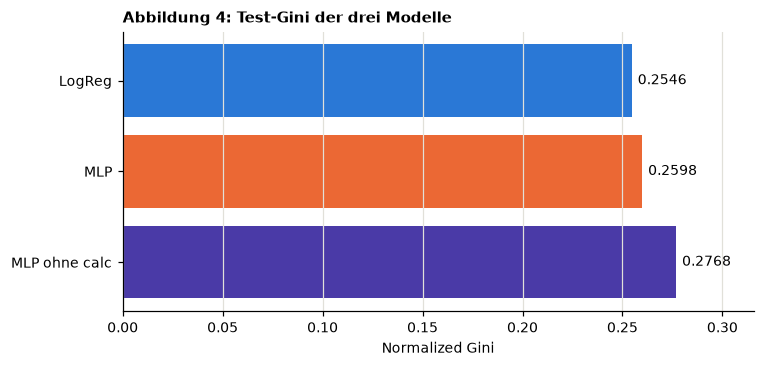

In [13]:
namen = list(ergebnisse)
gini_werte = [ergebnisse[name]["test"]["gini"] for name in namen]
fig, ax = plt.subplots(figsize=(7.4, 3.3))
balken = ax.barh(namen, gini_werte, color=[FARBEN[name] for name in namen])
ax.invert_yaxis(); ax.set_xlim(0, max(gini_werte) * 1.14)
ax.set_xlabel("Normalized Gini")
ax.set_title("Abbildung 4: Test-Gini der drei Modelle", loc="left")
ax.grid(axis="y", visible=False)
for balken_objekt, wert in zip(balken, gini_werte):
    ax.text(wert + 0.003,
            balken_objekt.get_y() + balken_objekt.get_height() / 2,
            f"{wert:.4f}", va="center")
speichern(fig, "nn_04_gini_vergleich.png")

**Abbildung 4:** Die Balken beginnen bei null; die exakten Gini-Werte stehen daneben.

*Take-away:* Das kleine MLP verbessert die logistische Baseline nur leicht (0,2598 statt
0,2546). Das MLP ohne calc erreicht auf diesem Testsplit mit 0,2768 den hoechsten Wert.

In [14]:
ausgabe = {
    "split": {"random_state": RANDOM_STATE,
              "n_train": int(len(y_train)), "n_test": int(len(y_test))},
    "modellparameter": {
        "hidden_layer_sizes": [64], "alpha": 1e-4,
        "batch_size": BATCH_SIZE, "max_iter": MAX_ITER,
        "early_stopping": True, "validation_fraction": 0.1,
        "n_iter_no_change": 10},
    "modelle": {
        name: {
            "test": {k: float(v) for k, v in eintrag["test"].items()},
            "fit_sekunden": float(eintrag["fit_sekunden"]),
            "epochen_iterationen": int(eintrag["epochen_iterationen"]),
            "features": int(eintrag["features"])}
        for name, eintrag in ergebnisse.items()},
    "versionen": VERSIONEN}
with open(ERG_JSON, "w", encoding="utf-8") as datei:
    json.dump(ausgabe, datei, indent=2, ensure_ascii=False)
print(f"Ergebnisse gespeichert: {ERG_JSON}")

Ergebnisse gespeichert: ergebnisse/ergebnisse_neural_network.json


## 9. Fazit und Grenzen

Das kleine MLP erreicht einen Test-Gini von 0,2598 und liegt damit 0,0052 ueber der
logistischen Regression. Ohne die 20 calc-Merkmale erreicht dieselbe MLP-Konfiguration
0,2768. Beide MLPs verwenden dieselbe automatische Trainingsregel; Early Stopping beendet
sie nach 16 beziehungsweise 19 Epochen. Der beobachtete Unterschied gehoert deshalb zum
Vergleich der gesamten Pipelines und laesst sich nicht allein der Merkmalsentfernung
zuschreiben.

Die wichtigste Grenze bleibt: Es wurde nur ein Train-Test-Split mit einem Seed verwendet.
Die Rangfolge ist daher eine Beobachtung dieses Splits und kein Nachweis fuer einen stabilen
Vorteil. Zudem ueberwacht das automatische Early Stopping Accuracy statt Gini. Learning
Curves, Dimensionsreduktion und eine breite Hyperparametersuche wurden nicht untersucht,
weil der individuelle Beitrag bewusst auf Baseline, ein kleines MLP und die calc-Variante
begrenzt wurde.

**Ergebnis:** Fuer diesen Split ist das MLP ohne calc der staerkste Kandidat. Fuer eine
allgemeine Empfehlung waeren wiederholte stratifizierte Splits oder Kreuzvalidierung noetig.

## 10. Quellen und Hilfsmittel

- Kaggle (2017): *Porto Seguro's Safe Driver Prediction.*
  https://www.kaggle.com/competitions/porto-seguro-safe-driver-prediction
  (Zugriff 17.08.2026)
- OpenML (2020): Datensatz *porto-seguro*, ID 42742, Version 3.
  https://www.openml.org/search?type=data&id=42742 (Zugriff 17.08.2026)
- scikit-learn developers (2026): *MLPClassifier*, API-Referenz zu Version 1.9.0.
  https://scikit-learn.org/1.9/modules/generated/sklearn.neural_network.MLPClassifier.html
  (Zugriff 26.08.2026)
- scikit-learn developers (2026): *Metrics and scoring*, User Guide zu Version 1.9.0.
  https://scikit-learn.org/1.9/modules/model_evaluation.html
  (Zugriff 26.08.2026)
- Jahrer (2017): *1st place with representation learning.*
  https://www.kaggle.com/competitions/porto-seguro-safe-driver-prediction/discussion/44629
  (Zugriff 17.08.2026)

| Python | scikit-learn | pandas | numpy | matplotlib |
|---|---|---|---|---|
| 3.14.6 | 1.9.0 | 3.0.3 | 2.5.1 | 3.11.0 |

**Einsatz generativer KI:** Claude Code und OpenAI Codex wurden fuer Planung,
Codepruefung, methodische Kontrolle und sprachliche Ueberarbeitung eingesetzt. Vorschlaege
wurden durch vollstaendige Notebooklaeufe und den Abgleich mit der Ergebnisdatei geprueft.
Der fruehere Ansatz mit eigener Epochensteuerung wurde verworfen, weil er fuer den
individuellen Beitrag unnoetig schwer zu erklaeren war. Ausfuehrliche Prompt-Beispiele stehen
im e-Portfolio.